# Phase-II Style Vector Computation

This notebook reproduces the feature extraction pipeline used in the phase-II workflow and operationalizes an eight-dimensional stylistic representation for character-level analysis.

## Generate Constituency Parse Trees

### Load Style Space (Training Set)

**V1 Dataset**

In [1]:
from pathlib import Path
from typing import List
import json

MUICE_PATH = Path("../Dataset/Muice/train.jsonl")
HARUHI_PATH = Path(r".\data\raw\Haruhi\Haruhi_clean.jsonl")
PSYDC_PATH1 = Path(r"..\Dataset\PsyDTCorpus\PsyDTCorpus_train_mulit_turn_packing.json")
PSYDC_PATH2 = Path(r"..\Dataset\PsyDTCorpus\PsyDTCorpus_test_single_turn_split.json")

# Check if Dataset exist
assert MUICE_PATH.is_file(), "请确保 Muice Dataset 的路径正确！"
assert HARUHI_PATH.is_file(), "请确保 Haruhi Dataset 的路径正确！"
assert PSYDC_PATH1.is_file(), "请确保 PsyDTCorpus Dataset 的路径正确！"

# Load Muice Dataset
dataset_lines = MUICE_PATH.read_text(encoding="utf-8").splitlines()

muice_responses: List[str] = []

for line in dataset_lines:
    item = json.loads(line)
    muice_responses.append(item["Response"])

# 出于计算效率，只取 80% 进行计算
muice_responses = muice_responses[:int(len(muice_responses)*0.8)]

# Load Haruhi Dataset
dataset_lines = HARUHI_PATH.read_text(encoding="utf-8").splitlines()

ayaka_responses: List[str] = []
zhongli_responses: List[str] = []
hutao_responses: List[str] = []
haruhi_responses: List[str] = []

for line in dataset_lines:
    item = json.loads(line)

    # 只提取单一角色的训练集
    if item["agent_role"] == "神里绫华":
        ayaka_responses.append(item["agent_response"])
    elif item["agent_role"] == "钟离":
        zhongli_responses.append(item["agent_response"])
    elif item["agent_role"] == "胡桃":
        hutao_responses.append(item["agent_response"])
    elif item["agent_role_name_en"] == "haruhi":
        haruhi_responses.append(item["agent_response"])

# 出于计算效率，只取 70% 进行计算
ayaka_responses = ayaka_responses[:int(len(ayaka_responses)*0.7)]
zhongli_responses = zhongli_responses[:int(len(zhongli_responses)*0.7)]
hutao_responses = hutao_responses[:int(len(hutao_responses)*0.7)]
haruhi_responses = haruhi_responses[:int(len(haruhi_responses)*0.7)]

# Load PsyDTCorpus Dataset
psydc_part1 = json.loads(PSYDC_PATH1.read_text(encoding="utf-8"))
psydc_part2 = json.loads(PSYDC_PATH2.read_text(encoding="utf-8"))
psydc: list[dict] = psydc_part1 + psydc_part2
psydc_responses: List[str] = []

for item in psydc:
    messages: list[dict[str, str]] = item["messages"]
    for index in range(2, len(messages), 2):
        message = messages[index]
        assert message["role"] == "assistant", message
        psydc_responses.append(message["content"])

# 取 70 %作为训练集
psydc_responses = psydc_responses[:int(len(psydc_responses)*0.7)]

# 输出所有训练集的长度

print(f"Muice Responses: {len(muice_responses)}")
print(f"Ayaka Responses: {len(ayaka_responses)}")
print(f"Zhongli Responses: {len(zhongli_responses)}")
print(f"Hutao Responses: {len(hutao_responses)}")
print(f"Haruhi Responses: {len(haruhi_responses)}")
print(f"PsyDTCorpus Responses: {len(psydc_responses)}")

Muice Responses: 2721
Ayaka Responses: 991
Zhongli Responses: 359
Hutao Responses: 591
Haruhi Responses: 770
PsyDTCorpus Responses: 89652


**V2 Dataset**

In [2]:
HARUHI_PATH2 = Path(r".\data\raw\Haruhi\Haruhi_clean.jsonl")
WUKONG_PATH = Path(r".\data\raw\wukong\wukong_dialog_qa.jsonl")

liyunlong_responses: List[str] = []
sheldon_responses: List[str] = []
wukong_responses: List[str] = []

assert HARUHI_PATH2.is_file(), "请确保 Haruhi Dataset 的路径正确！"
assert WUKONG_PATH.is_file(), "请确保 Wukong Dataset 的路径正确！"

dataset_lines = HARUHI_PATH2.read_text(encoding="utf-8").splitlines()

for line in dataset_lines:
    item = json.loads(line)

    # 只提取单一角色的训练集
    if item["agent_role"] == "李云龙":
        liyunlong_responses.append(item["agent_response"])
    elif item["agent_role"] == "Sheldon":
        sheldon_responses.append(item["agent_response"])

# 加载 Wukong Dataset
dataset_lines = WUKONG_PATH.read_text(encoding="utf-8").splitlines()

wukong_responses: List[str] = []
for line in dataset_lines:
    item = json.loads(line)
    wukong_responses.append(item["agent_response"])


print(f"Liyunlong Responses: {len(liyunlong_responses)}")
print(f"Sheldon Responses: {len(sheldon_responses)}")
print(f"Wukong Responses: {len(wukong_responses)}")



Liyunlong Responses: 1782
Sheldon Responses: 1886
Wukong Responses: 700


### Call HanLP for Constituency Parsing

In [5]:
from hanlp_restful import HanLPClient
from hanlp_common.document import Document
from time import sleep
from dotenv import load_dotenv
from os import getenv
import re

load_dotenv()

HanLP = HanLPClient('https://www.hanlp.com/api', auth=getenv("HANLP_API_KEY", None), language='zh')  # type: ignore

def limit_sentense_length(text: str, max_length: int = 150) -> list[str]:
    if len(text) <= max_length:
        return [text] if text.strip() else []
    
    # 按照标点符号进行分割
    sentences = re.split(r'([。！？；，,.!?;])', text)
    chunks: list[str] = []
    temp = ''
    for i in range(0, len(sentences), 2):
        chunk = sentences[i] + (sentences[i+1] if i+1 < len(sentences) else '')
        if not chunk.strip():
            continue

        if len(temp) + len(chunk) <= max_length:
            temp += chunk
        else:
            if temp.strip():
                chunks.append(temp)
            # 兜底处理：若单个片段本身超长，按最大长度硬切分
            if len(chunk) > max_length:
                for j in range(0, len(chunk), max_length):
                    piece = chunk[j:j + max_length]
                    if piece.strip():
                        chunks.append(piece)
                temp = ''
            else:
                temp = chunk
    if temp.strip():
        chunks.append(temp)
    return chunks

def split_texts(texts: list[str]) -> list[str]:
    """将文本列表中的每个文本分割成更小的句子"""
    all_sentences = []
    for text in texts:
        sentences = limit_sentense_length(text)
        all_sentences.extend(sentences)
    return all_sentences

def constituency_parsing_safe(texts: list[str], max_batch_num: int = 250, max_chars_per_batch: int = 15000, interval: int = 35) -> List[Document]:
    """对文本进行分词，同时限制每一批总字符数"""
    all_docs = []
    current_batch = []
    current_length = 0
    batch_id = 1

    for text in texts:
        text_len = len(text)

        # 如果加上这个句子会超出限制，则先处理已有批次
        if current_length + text_len > max_chars_per_batch or len(current_batch) + 1 > max_batch_num:
            print(f"Processing batch {batch_id} (Total chars: {current_length})...", end='')
            doc = HanLP.parse(current_batch, tasks=['pos', 'con'])
            all_docs.append(doc)
            print("done.")
            sleep(interval)

            batch_id += 1
            # 重置 batch
            current_batch = [text]
            current_length = text_len
        else:
            current_batch.append(text)
            current_length += text_len

    # 最后一批也别忘记
    if current_batch:
        print(f"Processing batch {batch_id} (Total chars: {current_length})...", end='')
        doc = HanLP.parse(current_batch, tasks=['pos', 'con'])
        all_docs.append(doc)
        print("done.")

    return all_docs

**V1 Dataset**

In [ ]:
muice_responses_split = split_texts(muice_responses)
ayaka_responses_split = split_texts(ayaka_responses)
zhongli_responses_split = split_texts(zhongli_responses)
hutao_responses_split = split_texts(hutao_responses)
haruhi_responses_split = split_texts(haruhi_responses)
psydc_responses_split = split_texts(psydc_responses)

muice_cons = constituency_parsing_safe(muice_responses_split, 200, interval=1)
ayaka_cons = constituency_parsing_safe(ayaka_responses_split, 200, interval=1)
zhongli_cons = constituency_parsing_safe(zhongli_responses_split, 200, interval=1)
hutao_cons = constituency_parsing_safe(hutao_responses_split, 200, interval=1)
haruhi_cons = constituency_parsing_safe(haruhi_responses_split, 200, interval=1)
psydc_cons = constituency_parsing_safe(psydc_responses_split, 200, interval=1)

Processing batch 1 (Total chars: 9118)...done.
Processing batch 2 (Total chars: 8006)...done.
Processing batch 3 (Total chars: 13423)...done.
Processing batch 4 (Total chars: 12001)...done.


**V2 Dataset**

In [6]:
liyunlong_responses_split = split_texts(liyunlong_responses)
sheldon_responses_split = split_texts(sheldon_responses)
wukong_responses_split = split_texts(wukong_responses)

liyunlong_cons = constituency_parsing_safe(liyunlong_responses_split, 200, interval=1)
sheldon_cons = constituency_parsing_safe(sheldon_responses_split, 200, interval=1)
wukong_cons = constituency_parsing_safe(wukong_responses_split, 200, interval=1)

Processing batch 1 (Total chars: 11720)...done.
Processing batch 2 (Total chars: 10484)...done.
Processing batch 3 (Total chars: 11746)...done.
Processing batch 4 (Total chars: 12177)...done.
Processing batch 5 (Total chars: 13932)...done.
Processing batch 6 (Total chars: 14922)...done.
Processing batch 7 (Total chars: 14997)...done.
Processing batch 8 (Total chars: 14927)...done.
Processing batch 9 (Total chars: 14996)...done.
Processing batch 10 (Total chars: 9986)...done.
Processing batch 1 (Total chars: 13413)...done.
Processing batch 2 (Total chars: 12250)...done.
Processing batch 3 (Total chars: 14046)...done.
Processing batch 4 (Total chars: 13637)...done.
Processing batch 5 (Total chars: 13142)...done.
Processing batch 6 (Total chars: 14002)...done.
Processing batch 7 (Total chars: 13917)...done.
Processing batch 8 (Total chars: 10738)...done.
Processing batch 9 (Total chars: 11893)...done.
Processing batch 10 (Total chars: 11633)...done.
Processing batch 1 (Total chars: 6816).

### Archive Raw Results to JSON File

In [ ]:
import json

def save_cons_to_json(cons_docs: List[Document], character: str):
    cons_json = [doc.to_dict() for doc in cons_docs]
    file_path = Path('./outputs/style/dense/diagnostics/cons') / f'{character}.json'
    file_path.parent.mkdir(parents=True, exist_ok=True)
    with open(file_path, 'w', encoding='utf-8') as f:
        json.dump(cons_json, f, ensure_ascii=False)

**V1 Dataset**

In [ ]:
save_cons_to_json(muice_cons, "muice")
save_cons_to_json(ayaka_cons, "ayaka")
save_cons_to_json(zhongli_cons, "zhongli")
save_cons_to_json(hutao_cons, "hutao")
save_cons_to_json(haruhi_cons, "haruhi")
save_cons_to_json(psydc_cons, "psydc")

**V2 Dataset**

In [9]:
save_cons_to_json(liyunlong_cons, "liyunlong")
save_cons_to_json(sheldon_cons, "sheldon")
save_cons_to_json(wukong_cons, "wukong")

## Experimental Setup and Global Configuration
This section defines corpus paths, role mappings, lexical heuristics, and syntactic tag sets used throughout the pipeline. The configuration is intentionally centralized to ensure consistency across feature extraction stages.

In [ ]:
import json
import re
from pathlib import Path

import pandas as pd

ROOT = Path()
CONS_DIR = ROOT / "outputs" / "style" / "dense" / "diagnostics" / "cons"
OUT_BASE = ROOT / "outputs" / "style"
DENSE_RAW_DIR = OUT_BASE / "dense" / "raw"
DENSE_NORM_DIR = OUT_BASE / "dense" / "normalized"
DENSE_DIAG_DIR = OUT_BASE / "dense" / "diagnostics"
SIGNATURE_PUNC_DIR = OUT_BASE / "signature" / "punctuation"
DENSE_RAW_DIR.mkdir(parents=True, exist_ok=True)
DENSE_NORM_DIR.mkdir(parents=True, exist_ok=True)
DENSE_DIAG_DIR.mkdir(parents=True, exist_ok=True)
SIGNATURE_PUNC_DIR.mkdir(parents=True, exist_ok=True)

STYLE_EXCLUDE_ROLES = {"PsyDC"}
OOD_HOLDOUT_ROLES = {"芙莉莲"}  # 保留用于域外测试，但不参与归一化统计量计算

ROLE_MAP = {
    "haruhi": "凉宫春日",
    "muice": "沐雪",
    "ayaka": "神里绫华",
    "hutao": "胡桃",
    "zhongli": "钟离",
    "frieren": "芙莉莲",
    "liyunlong": "李云龙",
    "sheldon": "Sheldon",
    "wukong": "孙悟空",
    "psydc": "PsyDC",
}

WH_WORDS = {
    "谁", "什么", "哪", "哪里", "怎么", "怎样", "为何", "为什么",
    "怎", "几", "多少", "孰", "何", "何必", "何苦"
}
SP_Q_WORDS = {"吗", "么", "吗呀"}
MODAL_Q_PAT = re.compile(r"(能不能|可不可以|要不要|是不是|会不会|行不行|好不好|该不该|应不应该|能否|是否|可否)")
A_NOT_A_PAT = re.compile(r"([\u4e00-\u9fffA-Za-z]{1,3})不\1")
REQUEST_START = {"请", "帮", "帮我", "麻烦", "别", "不要", "让", "快", "赶紧", "务必"}
REQUEST_ANY = {"请", "帮", "麻烦", "别", "不要", "快", "赶紧", "建议", "不如", "要不", "还是"}
VERB_POS = {"VV", "VA", "VC", "VE"}
NOUN_POS = {"NN", "NR", "NT"}
MARKER_POS = {"SP", "IJ", "INTJ", "MSP"}

## Core Syntactic Utilities and Tree Traversal
The following utilities implement leaf extraction, punctuation filtering, clause segmentation, and dependency-proxy distance calculations. These components provide the structural basis for all subsequent stylistic metrics.

In [5]:
def is_leaf(node):
    return (
        isinstance(node, list)
        and len(node) == 2
        and isinstance(node[0], str)
        and isinstance(node[1], list)
        and len(node[1]) == 1
        and isinstance(node[1][0], str)
    )


def get_leaves(node):
    if not isinstance(node, list):
        return []
    if is_leaf(node):
        return [(node[0], node[1][0])]
    leaves = []
    if len(node) == 2 and isinstance(node[0], str) and isinstance(node[1], list):
        for child in node[1]:
            leaves.extend(get_leaves(child))
    return leaves


def non_pu_tokens(leaves):
    return [(p, w) for p, w in leaves if p != "PU"]


def join_sentence(leaves):
    return "".join([w for _, w in leaves]).strip()


def split_into_clauses(leaves):
    split_pu = {"?", "？", "!", "！", "。", "~", "～", "…", "......"}
    clauses = []
    current = []

    for token in leaves:
        current.append(token)
        pos, word = token
        if pos == "PU" and word in split_pu:
            clauses.append(current)
            current = []

    if current:
        clauses.append(current)

    cleaned = []
    for clause in clauses:
        words = [w for p, w in clause if p != "PU"]
        if words:
            cleaned.append(clause)
    return cleaned


def get_leaf_paths(node, path=None, out=None):
    if path is None:
        path = []
    if out is None:
        out = []

    if not isinstance(node, list):
        return out

    if is_leaf(node):
        pos = node[0]
        word = node[1][0]
        out.append((pos, word, path + [pos]))
        return out

    if len(node) == 2 and isinstance(node[0], str) and isinstance(node[1], list):
        label = node[0]
        for child in node[1]:
            get_leaf_paths(child, path + [label], out)

    return out


def _lcp_len(a, b):
    n = min(len(a), len(b))
    k = 0
    while k < n and a[k] == b[k]:
        k += 1
    return k


def compute_constituency_mdd_proxy(tree):
    leaf_paths = get_leaf_paths(tree)
    content = [(p, w, path) for p, w, path in leaf_paths if p != "PU"]
    if len(content) <= 1:
        return 0.0

    distances = []
    for i in range(len(content) - 1):
        _, _, p1 = content[i]
        _, _, p2 = content[i + 1]
        lcp = _lcp_len(p1, p2)
        tree_dist = (len(p1) - lcp) + (len(p2) - lcp)
        distances.append(float(tree_dist))

    return sum(distances) / len(distances) if distances else 0.0


def _extract_head_index(item):
    if isinstance(item, int):
        return item
    if isinstance(item, dict):
        for k in ("head", "head_id", "governor", "gov"):
            if k in item and isinstance(item[k], int):
                return item[k]
    if isinstance(item, (list, tuple)) and item and isinstance(item[0], int):
        return item[0]
    return None


def compute_dependency_mdd(dep_sentence):
    if not isinstance(dep_sentence, list) or not dep_sentence:
        return None

    distances = []
    for i, arc in enumerate(dep_sentence, start=1):
        head = _extract_head_index(arc)
        if head is None:
            return None
        if head <= 0:
            continue
        distances.append(abs(i - head))

    return (sum(distances) / len(distances)) if distances else 0.0

## Discourse Marker Induction and Clause-Level Dialogue-Act Signals
This section induces candidate discourse markers from sentence boundaries and computes clause-level multi-hot dialogue-act indicators. The design balances linguistic interpretability and robustness to colloquial data.

In [6]:
def infer_discourse_marker_candidates(data):
    sent_total = 0
    start_counts = {}
    end_counts = {}

    for doc in data:
        trees = doc.get("con", [])
        for tree in trees:
            leaves = get_leaves(tree)
            if not leaves:
                continue
            no_pu = non_pu_tokens(leaves)
            if not no_pu:
                continue

            sent_total += 1
            sp, sw = no_pu[0]
            ep, ew = no_pu[-1]

            if len(sw) <= 2 and sp in MARKER_POS:
                start_counts[sw] = start_counts.get(sw, 0) + 1
            if len(ew) <= 2 and ep in MARKER_POS:
                end_counts[ew] = end_counts.get(ew, 0) + 1

    min_count = max(2, int(sent_total * 0.003)) if sent_total else 1

    start_candidates = sorted([w for w, c in start_counts.items() if c >= min_count], key=lambda w: (-start_counts[w], w))
    end_candidates = sorted([w for w, c in end_counts.items() if c >= min_count], key=lambda w: (-end_counts[w], w))

    return sent_total, start_counts, end_counts, start_candidates, end_candidates


def extract_clause_features(clause):
    no_pu = non_pu_tokens(clause)
    words = [w for _, w in no_pu]
    text = "".join(words)
    token_len = len(words)

    puncts = [w for p, w in clause if p == "PU"]
    has_qmark = any(p in {"?", "？"} for p in puncts)
    has_exclaim = any(p in {"!", "！"} for p in puncts)

    first_word = words[0] if words else ""
    first_pos = no_pu[0][0] if no_pu else ""
    request_start = first_word in REQUEST_START
    request_marker = any(w in REQUEST_ANY for w in words[:4])
    verb_start = first_pos in VERB_POS
    verb_count = sum(1 for p, _ in no_pu if p in VERB_POS)

    sentence_final_sp_q = False
    if no_pu:
        last_pos, last_word = no_pu[-1]
        sentence_final_sp_q = last_pos == "SP" and last_word in SP_Q_WORDS

    wh_in_first_three = any(w in WH_WORDS for w in words[:3])
    modal_pattern = bool(MODAL_Q_PAT.search(text))
    a_not_a_pattern = bool(A_NOT_A_PAT.search(text))

    has_intj = any(p in {"IJ", "INTJ"} for p, _ in no_pu)
    short_intj = has_intj and token_len <= 3

    fragment_short = token_len <= 3
    fragment_no_verb = verb_count == 0

    return {
        "token_len": token_len,
        "has_qmark": has_qmark,
        "has_exclaim": has_exclaim,
        "sentence_final_sp_q": sentence_final_sp_q,
        "wh_in_first_three": wh_in_first_three,
        "modal_pattern": modal_pattern,
        "a_not_a_pattern": a_not_a_pattern,
        "request_start": request_start,
        "request_marker": request_marker,
        "verb_start": verb_start,
        "short_intj": short_intj,
        "fragment_short": fragment_short,
        "fragment_no_verb": fragment_no_verb,
    }


def score_clause(feat):
    score_question = (
        3 * int(feat["has_qmark"])
        + 2 * int(feat["modal_pattern"])
        + 2 * int(feat["a_not_a_pattern"])
        + 1 * int(feat["sentence_final_sp_q"])
        + 1 * int(feat["wh_in_first_three"])
    )

    score_imperative = (
        2 * int(feat["request_start"])
        + 1 * int(feat["request_marker"])
        + 1 * int(feat["verb_start"])
    )

    score_exclamation = 3 * int(feat["has_exclaim"]) + 1 * int(feat["short_intj"])
    score_fragment = 2 * int(feat["fragment_short"]) + 2 * int(feat["fragment_no_verb"])

    multi_hot = {
        "question": int(score_question >= 2),
        "imperative": int(score_imperative >= 2),
        "exclamation": int(score_exclamation >= 2),
        "fragment": int(score_fragment >= 3),
    }

    if sum(multi_hot.values()) == 0:
        multi_hot["declarative"] = 1
    else:
        multi_hot["declarative"] = 0

    return multi_hot

## Character-Level Metric Estimation and Eight-Dimensional Vector Assembly
Here we aggregate sentence- and clause-level statistics into role-specific metrics and construct the final eight-dimensional representation required by the phase-II framework.

In [7]:
def compute_role_metrics(cons_path):
    data = json.loads(cons_path.read_text(encoding="utf-8"))

    sent_total, _, _, start_candidates, end_candidates = infer_discourse_marker_candidates(data)
    marker_start = {m: 0 for m in start_candidates}
    marker_end = {m: 0 for m in end_candidates}

    token_total = 0
    verb_total = 0
    noun_total = 0
    sentence_scanned = 0

    mdd_values = []
    multi_counts = {"question": 0, "imperative": 0, "exclamation": 0, "fragment": 0, "declarative": 0}
    total_clauses = 0

    punc_hits = {
        "multi_exclamation": 0,
        "multi_question": 0,
        "interrobang": 0,
        "ellipsis": 0,
        "multi_tilde": 0,
    }

    for doc in data:
        trees = doc.get("con", [])
        dep_doc = doc.get("dep", [])

        for sent_idx, tree in enumerate(trees):
            leaves = get_leaves(tree)
            if not leaves:
                continue

            no_pu = non_pu_tokens(leaves)
            if not no_pu:
                continue

            sentence_scanned += 1
            words = [w for _, w in no_pu]
            token_total += len(words)

            for pos, _ in no_pu:
                if pos in VERB_POS:
                    verb_total += 1
                if pos in NOUN_POS:
                    noun_total += 1

            if words and words[0] in marker_start:
                marker_start[words[0]] += 1
            if words and words[-1] in marker_end:
                marker_end[words[-1]] += 1

            sentence_text = join_sentence(leaves)
            if re.search(r"[!！]{2,}", sentence_text):
                punc_hits["multi_exclamation"] += 1
            if re.search(r"[?？]{2,}", sentence_text):
                punc_hits["multi_question"] += 1
            if re.search(r"([?？][!！]|[!！][?？])", sentence_text):
                punc_hits["interrobang"] += 1
            if re.search(r"(……|\.{3,}|…{2,}|。{2,})", sentence_text):
                punc_hits["ellipsis"] += 1
            if re.search(r"[~～]{2,}", sentence_text):
                punc_hits["multi_tilde"] += 1

            mdd = None
            if isinstance(dep_doc, list) and sent_idx < len(dep_doc):
                mdd = compute_dependency_mdd(dep_doc[sent_idx])
            if mdd is None:
                mdd = compute_constituency_mdd_proxy(tree)
            mdd_values.append(mdd)

            for clause in split_into_clauses(leaves):
                feat = extract_clause_features(clause)
                mh = score_clause(feat)
                total_clauses += 1
                for k in multi_counts:
                    multi_counts[k] += mh.get(k, 0)

    sentence_count = sentence_scanned if sentence_scanned else sent_total
    avg_utterance_len = (token_total / sent_total) if sent_total else 0.0
    mdd = (sum(mdd_values) / len(mdd_values)) if mdd_values else 0.0
    verb_noun_ratio = (verb_total / noun_total) if noun_total else 0.0

    marker_start_total = sum(marker_start.values())
    marker_end_total = sum(marker_end.values())
    marker_density = ((marker_start_total + marker_end_total) / (2 * sentence_count)) if sentence_count else 0.0

    punc_ratios = {k: (v / sentence_count if sentence_count else 0.0) for k, v in punc_hits.items()}
    punc_intensity = sum(punc_ratios.values())

    multihot_ratio = {k: (v / total_clauses if total_clauses else 0.0) for k, v in multi_counts.items()}

    return {
        "avg_utterance_len": avg_utterance_len,
        "MDD": mdd,
        "verb_noun_ratio": verb_noun_ratio,
        "question_ratio": multihot_ratio["question"],
        "imperative_ratio": multihot_ratio["imperative"],
        "fragment_ratio": multihot_ratio["fragment"],
        "marker_density": marker_density,
        "punc_intensity": punc_intensity,
        "sentence_count": sentence_count,
        "total_clauses": total_clauses,
        "marker_start_total": marker_start_total,
        "marker_end_total": marker_end_total,
        "punc_ratios": punc_ratios,
    }


rows = []
for cons_path in sorted(CONS_DIR.glob("*.json")):
    role = ROLE_MAP.get(cons_path.stem, cons_path.stem)
    if role in STYLE_EXCLUDE_ROLES:
        continue

    vec = compute_role_metrics(cons_path)
    vec["role"] = role
    vec["role_split"] = "ood_holdout" if role in OOD_HOLDOUT_ROLES else "train"
    rows.append(vec)

df = pd.DataFrame(rows)[[
    "role",
    "role_split",
    "avg_utterance_len",
    "MDD",
    "verb_noun_ratio",
    "question_ratio",
    "imperative_ratio",
    "fragment_ratio",
    "marker_density",
    "punc_intensity",
]]
df

,role,role_split,avg_utterance_len,MDD,verb_noun_ratio,question_ratio,imperative_ratio,fragment_ratio,marker_density,punc_intensity
0,神里绫华,train,41.556405,4.283726,1.002800,0.061573,0.009026,0.018053,0.115679,0.003824
1,芙莉莲,ood_holdout,9.080000,4.126499,1.828571,0.040000,0.000000,0.000000,0.220000,0.000000
2,凉宫春日,train,29.180556,4.313969,1.268221,0.163422,0.014033,0.064735,0.255682,0.008838
3,胡桃,train,43.698234,4.509816,1.268107,0.103402,0.017010,0.047001,0.483146,0.016051
4,李云龙,train,37.719892,4.314205,1.389616,0.196211,0.049918,0.058814,0.098387,0.006989
5,沐雪,train,16.223374,4.210868,1.655857,0.174822,0.023202,0.050770,0.256076,0.124732
6,Sheldon,train,34.308617,4.228445,0.927005,0.133702,0.021938,0.042667,0.280812,0.010020
7,孙悟空,train,21.880000,4.279716,1.441355,0.155963,0.016231,0.035992,0.132143,0.000000
8,钟离,train,39.660622,4.259045,0.927587,0.102007,0.013378,0.050167,0.089378,0.025907


## Robust Scaling with Bounded Projection for Cross-Role Comparability
This section first applies robust scaling (median and IQR) using only training roles, then projects values to [0, 1] with train-fitted bounds. The design preserves out-of-domain role vectors while preventing range explosion.

In [10]:
vector_cols = [
    "avg_utterance_len",
    "MDD",
    "verb_noun_ratio",
    "question_ratio",
    "imperative_ratio",
    "fragment_ratio",
    "marker_density",
    "punc_intensity",
]

# 仅基于训练角色拟合 Robust Scaler 统计量；域外角色（如 frieren）只做变换不参与拟合。
train_mask = df["role_split"] == "train"
train_ref = df.loc[train_mask, vector_cols]

norm_df = df.copy()
for col in vector_cols:
    median = train_ref[col].median()
    q1 = train_ref[col].quantile(0.25)
    q3 = train_ref[col].quantile(0.75)
    iqr = q3 - q1

    if iqr > 0:
        # Step 1: robust scaling
        train_robust = (train_ref[col] - median) / iqr
        all_robust = (norm_df[col] - median) / iqr

        # Step 2: use train-only robust range for [0,1] projection
        rmin = train_robust.min()
        rmax = train_robust.max()
        if rmax > rmin:
            projected = (all_robust - rmin) / (rmax - rmin)
            norm_df[col] = projected.clip(0.0, 1.0).round(4)
        else:
            norm_df[col] = 0.0
    else:
        norm_df[col] = 0.0

norm_df

,role,role_split,avg_utterance_len,MDD,verb_noun_ratio,question_ratio,imperative_ratio,fragment_ratio,marker_density,punc_intensity
0,神里绫华,train,0.9220,0.2437,0.1040,0.0000,0.0000,0.0000,0.0668,0.0307
1,芙莉莲,ood_holdout,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.3317,0.0000
2,凉宫春日,train,0.4716,0.3449,0.4682,0.7565,0.1224,1.0000,0.4223,0.0709
3,胡桃,train,1.0000,1.0000,0.4680,0.3107,0.1952,0.6201,1.0000,0.1287
4,李云龙,train,0.7824,0.3457,0.6347,1.0000,1.0000,0.8732,0.0229,0.0560
5,沐雪,train,0.0000,0.0000,1.0000,0.8411,0.3467,0.7008,0.4233,1.0000
6,Sheldon,train,0.6582,0.0588,0.0000,0.5357,0.3158,0.5273,0.4862,0.0803
7,孙悟空,train,0.2059,0.2303,0.7057,0.7011,0.1762,0.3843,0.1086,0.0000
8,钟离,train,0.8530,0.1612,0.0008,0.3003,0.1064,0.6879,0.0000,0.2077


### OOD Role Handling under Robust Scaling
For `frieren`, we keep the vector for out-of-domain evaluation, but exclude it from fitting robust statistics (`median`, `Q1`, `Q3`, `IQR`) and projection bounds. Fitted parameters come from `role_split == "train"` only, then are applied to all roles and clipped into [0, 1].

## Export of Reproducible Artifacts
The final step persists both raw and normalized vectors in JSON and CSV formats, ensuring traceability and straightforward integration with subsequent training and evaluation pipelines.

In [ ]:
raw_json_path = DENSE_RAW_DIR / "style_vector_phase2_raw.json"
norm_json_path = DENSE_NORM_DIR / "style_vector_phase2_robust_bounded.json"
raw_csv_path = DENSE_RAW_DIR / "style_vector_phase2_raw.csv"
norm_csv_path = DENSE_NORM_DIR / "style_vector_phase2_robust_bounded.csv"

raw_json_path.write_text(df.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
norm_json_path.write_text(norm_df.to_json(orient="records", force_ascii=False, indent=2), encoding="utf-8")
df.to_csv(raw_csv_path, index=False, encoding="utf-8-sig")
norm_df.to_csv(norm_csv_path, index=False, encoding="utf-8-sig")

print("saved:")
print(raw_json_path)
print(norm_json_path)
print(raw_csv_path)
print(norm_csv_path)

saved:
outputs\dialogue_act_scoring\style_vector_phase2_raw.json
outputs\dialogue_act_scoring\style_vector_phase2_minmax.json
outputs\dialogue_act_scoring\style_vector_phase2_raw.csv
outputs\dialogue_act_scoring\style_vector_phase2_minmax.csv


## Symbolic Signature Modeling ($S_{signature}$)

In [ ]:
import unicodedata
from collections import defaultdict

COMPOSITE_PATTERNS = {
    "multi_exclamation": re.compile(r"[!！]{2,}"),
    "multi_question": re.compile(r"[?？]{2,}"),
    "interrobang": re.compile(r"([?？][!！]|[!！][?？])"),
    "ellipsis": re.compile(r"(……|\.{3,}|…{2,}|。{2,})"),
    "multi_tilde": re.compile(r"[~～]{2,}"),
}

COMPOSITE_LABELS = {
    "multi_exclamation": "multi-!",
    "multi_question": "multi-?",
    "interrobang": "?!",
    "ellipsis": "...",
    "multi_tilde": "~~",
}

ACTIVE_THRESHOLD = 0.0005

# 覆盖常见 emoji 主区段（可按需要扩展）。
EMOJI_CHAR_RE = re.compile(
    "["
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA00-\U0001FAFF"
    "\U00002700-\U000027BF"  # dingbats
    "\U00002600-\U000026FF"  # misc symbols
    "]"
)

# 将常见 CJK 句读符排除，聚焦“特殊”标点/符号。
BASIC_PUNCT = set("，。！？、；：,.!?;:()（）【】[]《》<>「 」『』\"'“”‘’—-…~～ \n\t")

# 对话轮次来源：优先使用原始角色 responses（每条 response 视为 1 个对话轮次）。
ROLE_TURN_TEXTS = {
    "muice": muice_responses if "muice_responses" in globals() else [],
    "ayaka": ayaka_responses if "ayaka_responses" in globals() else [],
    "zhongli": zhongli_responses if "zhongli_responses" in globals() else [],
    "hutao": hutao_responses if "hutao_responses" in globals() else [],
    "haruhi": haruhi_responses if "haruhi_responses" in globals() else [],
    "liyunlong": liyunlong_responses if "liyunlong_responses" in globals() else [],
    "sheldon": sheldon_responses if "sheldon_responses" in globals() else [],
    "wukong": wukong_responses if "wukong_responses" in globals() else [],
    # psydc 被 STYLE_EXCLUDE_ROLES 排除，这里保留映射仅作完整性。
    "psydc": psydc_responses if "psydc_responses" in globals() else [],
}

def iter_sentence_texts(cons_data: list[dict]) -> list[str]:
    texts: list[str] = []
    for doc in cons_data:
        trees = doc.get("con", [])
        for tree in trees:
            leaves = get_leaves(tree)
            if not leaves:
                continue
            text = join_sentence(leaves)
            if text:
                texts.append(text)
    return texts

def extract_emoji_symbols(text: str) -> set[str]:
    return set(EMOJI_CHAR_RE.findall(text))

def extract_special_unicode_symbols(text: str, emoji_symbols: set[str]) -> set[str]:
    symbols = set()
    for ch in text:
        if ch in BASIC_PUNCT or ch in emoji_symbols:
            continue
        cat = unicodedata.category(ch)
        # P*: punctuation, S*: symbol
        if (cat.startswith("P") or cat.startswith("S")) and ord(ch) > 127:
            symbols.add(ch)
    return symbols

def get_turn_texts_for_role(cons_path: Path) -> list[str]:
    stem = cons_path.stem
    turns = ROLE_TURN_TEXTS.get(stem, [])
    if turns:
        return [t for t in turns if isinstance(t, str) and t.strip()]

    # 回退逻辑：若缺少原始对话轮次，退化为已解析文本（近似）。
    data = json.loads(cons_path.read_text(encoding="utf-8"))
    return iter_sentence_texts(data)

def compute_signature_for_role(cons_path: Path) -> dict:
    turn_texts = get_turn_texts_for_role(cons_path)
    turn_count = len(turn_texts)

    composite_turn_hits = {k: 0 for k in COMPOSITE_PATTERNS}
    special_symbol_hits = defaultdict(int)
    emoji_symbol_hits = defaultdict(int)

    for text in turn_texts:
        # 复合标点：按轮次命中
        for k, pat in COMPOSITE_PATTERNS.items():
            if pat.search(text):
                composite_turn_hits[k] += 1

        # 单符号：按轮次命中（同一轮出现多次只记 1 次）
        emoji_symbols = extract_emoji_symbols(text)
        special_symbols = extract_special_unicode_symbols(text, emoji_symbols)

        for sym in emoji_symbols:
            emoji_symbol_hits[sym] += 1
        for sym in special_symbols:
            special_symbol_hits[sym] += 1

    activity_scores = {
        COMPOSITE_LABELS[k]: round((v / turn_count) if turn_count else 0.0, 4)
        for k, v in composite_turn_hits.items()
    }

    for sym, hit in special_symbol_hits.items():
        activity_scores[sym] = round((hit / turn_count) if turn_count else 0.0, 4)
    for sym, hit in emoji_symbol_hits.items():
        activity_scores[sym] = round((hit / turn_count) if turn_count else 0.0, 4)

    active_items = [
        (sym, prob) for sym, prob in activity_scores.items() if prob >= ACTIVE_THRESHOLD
    ]
    active_items.sort(key=lambda x: (-x[1], x[0]))
    active_symbols = [sym for sym, _ in active_items]

    # S_signature 仅为文本列表，与具体数值解耦。
    s_signature = active_symbols

    return {
        "turn_count": turn_count,
        "activity_scores": activity_scores,
        "S_signature": s_signature,
    }

# 构建角色级 S_signature（文本列表）与独立数值诊断表
signature_rows = []
signature_stats_rows = []
for cons_path in sorted(CONS_DIR.glob("*.json")):
    role = ROLE_MAP.get(cons_path.stem, cons_path.stem)
    if role in STYLE_EXCLUDE_ROLES:
        continue

    sig = compute_signature_for_role(cons_path)
    signature_rows.append({
        "role": role,
        "S_signature": sig["S_signature"],
    })

    signature_stats_rows.append({
        "role": role,
        "turn_count": sig["turn_count"],
        "activity_scores": sig["activity_scores"],
    })

signature_df = pd.DataFrame(signature_rows).sort_values("role").reset_index(drop=True)
signature_stats_df = pd.DataFrame(signature_stats_rows).sort_values("role").reset_index(drop=True)

# 将 activity_scores 展开为长表，便于查看“单个符号”的概率。
symbol_stats_rows = []
for _, row in signature_stats_df.iterrows():
    role = row["role"]
    turn_count = row["turn_count"]
    scores: dict[str, float] = row["activity_scores"]
    for symbol, prob in scores.items():
        symbol_stats_rows.append({
            "role": role,
            "turn_count": turn_count,
            "symbol": symbol,
            "turn_prob": prob,
            "is_active": int(prob >= ACTIVE_THRESHOLD),
        })

symbol_stats_df = pd.DataFrame(symbol_stats_rows).sort_values(["role", "turn_prob", "symbol"], ascending=[True, False, True]).reset_index(drop=True)

# 独立输出活跃符号列表（即 S_signature）
print(f"Active symbol threshold = {ACTIVE_THRESHOLD}")
for _, row in signature_df.iterrows():
    symbols = row["S_signature"]
    print(f"{row['role']}: {', '.join(symbols) if symbols else '(none)'}")

print("\nTop active symbols per role (turn_prob >= threshold):")
active_view = symbol_stats_df[symbol_stats_df["is_active"] == 1].copy()
display(active_view)

# 保存符号建模结果
signature_out_dir = SIGNATURE_PUNC_DIR
signature_out_dir.mkdir(parents=True, exist_ok=True)

signature_json_path = signature_out_dir / "symbol_signature.json"
signature_csv_path = signature_out_dir / "symbol_signature.csv"
symbol_stats_json_path = signature_out_dir / "symbol_stats_turn_prob.json"
symbol_stats_csv_path = signature_out_dir / "symbol_stats_turn_prob.csv"
active_symbols_json_path = signature_out_dir / "active_symbols_turn_prob.json"
active_symbols_csv_path = signature_out_dir / "active_symbols_turn_prob.csv"

signature_json_path.write_text(
    signature_df.to_json(orient="records", force_ascii=False, indent=2),
    encoding="utf-8",
)
signature_df.to_csv(signature_csv_path, index=False, encoding="utf-8-sig")

symbol_stats_json_path.write_text(
    symbol_stats_df.to_json(orient="records", force_ascii=False, indent=2),
    encoding="utf-8",
)
symbol_stats_df.to_csv(symbol_stats_csv_path, index=False, encoding="utf-8-sig")

active_view.to_json(active_symbols_json_path, orient="records", force_ascii=False, indent=2)
active_view.to_csv(active_symbols_csv_path, index=False, encoding="utf-8-sig")

print("\nsaved:")
print(signature_json_path)
print(signature_csv_path)
print(symbol_stats_json_path)
print(symbol_stats_csv_path)
print(active_symbols_json_path)
print(active_symbols_csv_path)

signature_df

Active symbol threshold = 0.0005
Sheldon: ·, ..., multi-!
凉宫春日: ..., ·
孙悟空: (none)
李云龙: ?!, ...
沐雪: ..., ⭐, ?!, multi-!, ▽, ·, ∠, ⌒, ★, •, ≦, ≧, ♪, ❤, ・
神里绫华: ⋯, ...
胡桃: ..., ♪
芙莉莲: (none)
钟离: ...

Top active symbols per role (turn_prob >= threshold):


,role,turn_count,symbol,turn_prob,is_active
0,Sheldon,1886,·,0.0308,1
1,Sheldon,1886,...,0.0101,1
2,Sheldon,1886,multi-!,0.0005,1
6,凉宫春日,770,...,0.0091,1
7,凉宫春日,770,·,0.0013,1
17,李云龙,1782,?!,0.0056,1
18,李云龙,1782,...,0.0017,1
22,沐雪,2721,...,0.1246,1
23,沐雪,2721,⭐,0.0265,1
24,沐雪,2721,?!,0.0022,1



saved:
outputs\dialogue_act_scoring\symbol_signature\symbol_signature.json
outputs\dialogue_act_scoring\symbol_signature\symbol_signature.csv
outputs\dialogue_act_scoring\symbol_signature\symbol_stats_turn_prob.json
outputs\dialogue_act_scoring\symbol_signature\symbol_stats_turn_prob.csv
outputs\dialogue_act_scoring\symbol_signature\active_symbols_turn_prob.json
outputs\dialogue_act_scoring\symbol_signature\active_symbols_turn_prob.csv


,role,S_signature
0,Sheldon,"[·, ..., multi-!]"
1,凉宫春日,"[..., ·]"
2,孙悟空,[]
3,李云龙,"[?!, ...]"
4,沐雪,"[..., ⭐, ?!, multi-!, ▽, ·, ∠, ⌒, ★, •, ≦, ≧, ..."
5,神里绫华,"[⋯, ...]"
6,胡桃,"[..., ♪]"
7,芙莉莲,[]
8,钟离,[...]


## (Optional) Find Useless Vector

### Correlation Matrix Diagnostics (Pearson and Spearman)
This step quantifies pairwise feature associations to identify multicollinearity before dimensionality reduction. We flag feature pairs with absolute correlation above a predefined threshold and report whether `MDD` is redundant with `avg_utterance_len`.

In [ ]:
corr_features = [
    "avg_utterance_len",
    "MDD",
    "verb_noun_ratio",
    "question_ratio",
    "imperative_ratio",
    "fragment_ratio",
    "marker_density",
    "punc_intensity",
]

corr_data = df[corr_features].copy()
pearson_corr = corr_data.corr(method="pearson")
spearman_corr = corr_data.corr(method="spearman")

print("Pearson correlation matrix:")
display(pearson_corr.round(4))

print("Spearman correlation matrix:")
display(spearman_corr.round(4))

def high_corr_pairs(corr_matrix, threshold=0.85):
    pairs = []
    cols = list(corr_matrix.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = corr_matrix.iloc[i, j]
            if abs(v) > threshold:
                pairs.append((cols[i], cols[j], float(v)))
    return sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

threshold = 0.85
pearson_high = high_corr_pairs(pearson_corr, threshold=threshold)
spearman_high = high_corr_pairs(spearman_corr, threshold=threshold)

print(f"High-correlation pairs (|r| > {threshold}) in Pearson:")
if pearson_high:
    for a, b, r in pearson_high:
        print(f"  {a} vs {b}: r = {r:.4f}")
else:
    print("  None")

print(f"High-correlation pairs (|rho| > {threshold}) in Spearman:")
if spearman_high:
    for a, b, rho in spearman_high:
        print(f"  {a} vs {b}: rho = {rho:.4f}")
else:
    print("  None")

mdd_len_pearson = float(pearson_corr.loc["MDD", "avg_utterance_len"])  # type: ignore
mdd_len_spearman = float(spearman_corr.loc["MDD", "avg_utterance_len"])  # type: ignore
print("\nTarget check: MDD vs avg_utterance_len")
print(f"  Pearson r = {mdd_len_pearson:.4f}")
print(f"  Spearman rho = {mdd_len_spearman:.4f}")

if abs(mdd_len_pearson) > threshold or abs(mdd_len_spearman) > threshold:
    print("  Decision: Potential redundancy detected. Consider dropping MDD or replacing it with a more orthogonal feature.")
else:
    print("  Decision: No severe redundancy under the current threshold; keep MDD for now.")

Pearson correlation matrix:


,avg_utterance_len,MDD,verb_noun_ratio,question_ratio,imperative_ratio,fragment_ratio,marker_density,punc_intensity
avg_utterance_len,1.0000,0.7677,-0.9117,-0.0520,0.2534,0.3467,0.0614,-0.3489
MDD,0.7677,1.0000,-0.4730,0.1917,0.4434,0.4860,0.6790,-0.1930
verb_noun_ratio,-0.9117,-0.4730,1.0000,0.0244,-0.1675,-0.3559,0.3233,0.3362
question_ratio,-0.0520,0.1917,0.0244,1.0000,0.8519,0.8807,0.2357,0.6695
imperative_ratio,0.2534,0.4434,-0.1675,0.8519,1.0000,0.8136,0.3373,0.7455
fragment_ratio,0.3467,0.4860,-0.3559,0.8807,0.8136,1.0000,0.2487,0.3706
marker_density,0.0614,0.6790,0.3233,0.2357,0.3373,0.2487,1.0000,0.0684
punc_intensity,-0.3489,-0.1930,0.3362,0.6695,0.7455,0.3706,0.0684,1.0000


Spearman correlation matrix:


,avg_utterance_len,MDD,verb_noun_ratio,question_ratio,imperative_ratio,fragment_ratio,marker_density,punc_intensity
avg_utterance_len,1.0000,0.8286,-0.7714,0.0286,0.2000,-0.0286,0.0857,0.1429
MDD,0.8286,1.0000,-0.4857,0.3143,0.3714,0.3143,0.3714,0.0857
verb_noun_ratio,-0.7714,-0.4857,1.0000,0.0857,0.0286,-0.0857,0.4857,-0.2571
question_ratio,0.0286,0.3143,0.0857,1.0000,0.9429,0.8857,0.6000,0.7714
imperative_ratio,0.2000,0.3714,0.0286,0.9429,1.0000,0.7143,0.7143,0.8286
fragment_ratio,-0.0286,0.3143,-0.0857,0.8857,0.7143,1.0000,0.2571,0.6571
marker_density,0.0857,0.3714,0.4857,0.6000,0.7143,0.2571,1.0000,0.2571
punc_intensity,0.1429,0.0857,-0.2571,0.7714,0.8286,0.6571,0.2571,1.0000


High-correlation pairs (|r| > 0.85) in Pearson:
  avg_utterance_len vs verb_noun_ratio: r = -0.9117
  question_ratio vs fragment_ratio: r = 0.8807
  question_ratio vs imperative_ratio: r = 0.8519
High-correlation pairs (|rho| > 0.85) in Spearman:
  question_ratio vs imperative_ratio: rho = 0.9429
  question_ratio vs fragment_ratio: rho = 0.8857

Target check: MDD vs avg_utterance_len
  Pearson r = 0.7677
  Spearman rho = 0.8286
  Decision: No severe redundancy under the current threshold; keep MDD for now.


### PCA Validation after Feature Pruning
Following the correlation diagnostics, we remove `avg_utterance_len` and perform PCA on the remaining seven dimensions. The analysis reports explained variance ratios and visual separability in the two-dimensional principal-component space.

Selected 7-D features: ['MDD', 'verb_noun_ratio', 'question_ratio', 'imperative_ratio', 'fragment_ratio', 'marker_density', 'punc_intensity']
Explained variance ratio by component:
  PC1: 0.4957
  PC2: 0.2574
  PC3: 0.1909
  PC4: 0.0526
  PC5: 0.0033
  PC6: 0.0000

PC1 + PC2 explained variance: 0.7531
Decision: The first two PCs do not reach 90%; retain more PCs for faithful representation.

Quadrant occupancy:
role role_en quadrant
神里绫华   Ayaka       Q1
 芙莉莲 Frieren       Q4
凉宫春日  Haruhi       Q2
  胡桃  Hu Tao       Q2
  沐雪   Muice       Q3
  钟离 Zhongli       Q1


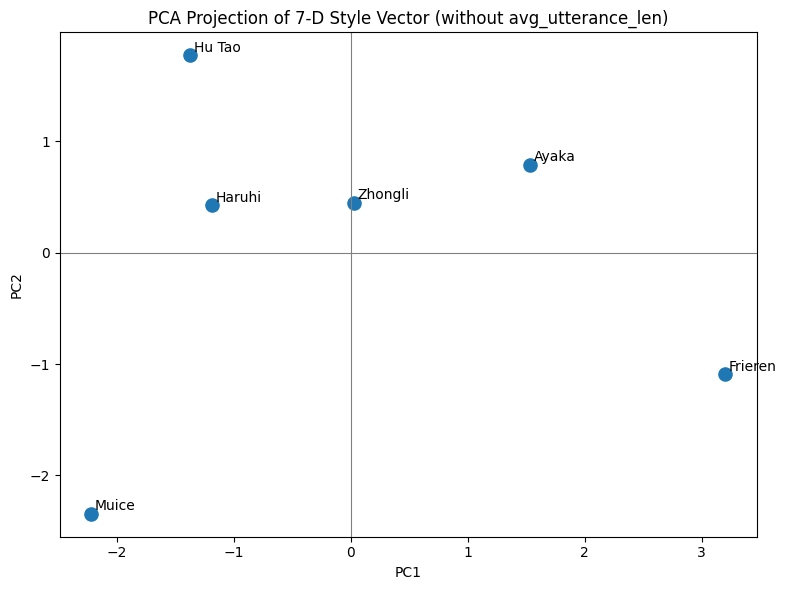

,role,role_en,PC1,PC2,quadrant
0,神里绫华,Ayaka,1.534130,0.787666,Q1
1,芙莉莲,Frieren,3.205082,-1.088507,Q4
2,凉宫春日,Haruhi,-1.182477,0.426938,Q2
3,胡桃,Hu Tao,-1.370495,1.769511,Q2
4,沐雪,Muice,-2.217250,-2.343636,Q3
5,钟离,Zhongli,0.031010,0.448028,Q1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Decision override: prune avg_utterance_len and keep a 7-D feature set.
selected_features = [
    "MDD",
    "verb_noun_ratio",
    "question_ratio",
    "imperative_ratio",
    "fragment_ratio",
    "marker_density",
    "punc_intensity",
]

# Use English labels in figures to avoid CJK glyph warnings on environments
# where Matplotlib falls back to DejaVu Sans without Chinese glyph support.
role_en_map = {
    "神里绫华": "Ayaka",
    "芙莉莲": "Frieren",
    "凉宫春日": "Haruhi",
    "胡桃": "Hu Tao",
    "沐雪": "Muice",
    "钟离": "Zhongli",
}

X = df[selected_features].to_numpy(dtype=float)
roles = df["role"].tolist()

# Standardization (z-score) for scale-invariant PCA.
mu = X.mean(axis=0, keepdims=True)
sigma = X.std(axis=0, ddof=0, keepdims=True)
sigma[sigma == 0] = 1.0
Z = (X - mu) / sigma

# PCA via SVD: Z = U S V^T, principal scores = U S.
U, S, Vt = np.linalg.svd(Z, full_matrices=False)
scores = U * S
eigvals = (S ** 2) / (len(Z) - 1) if len(Z) > 1 else np.array([0.0] * len(S))
explained_ratio = eigvals / eigvals.sum() if eigvals.sum() > 0 else np.zeros_like(eigvals)

pc_df = df[["role"]].copy()
pc_df["role_en"] = pc_df["role"].map(role_en_map).fillna(pc_df["role"])
pc_df["PC1"] = scores[:, 0] if scores.shape[1] > 0 else 0.0
pc_df["PC2"] = scores[:, 1] if scores.shape[1] > 1 else 0.0

print("Selected 7-D features:", selected_features)
print("Explained variance ratio by component:")
for i, r in enumerate(explained_ratio, start=1):
    print(f"  PC{i}: {r:.4f}")

pc12 = explained_ratio[:2].sum() if explained_ratio.size >= 2 else explained_ratio.sum()
print(f"\nPC1 + PC2 explained variance: {pc12:.4f}")
if pc12 >= 0.90:
    print("Decision: The first two PCs capture >= 90% variance.")
else:
    print("Decision: The first two PCs do not reach 90%; retain more PCs for faithful representation.")

# Quadrant occupancy in the PC1-PC2 plane.
def quadrant(x, y):
    if x >= 0 and y >= 0:
        return "Q1"
    if x < 0 and y >= 0:
        return "Q2"
    if x < 0 and y < 0:
        return "Q3"
    return "Q4"

pc_df["quadrant"] = [quadrant(x, y) for x, y in zip(pc_df["PC1"], pc_df["PC2"])]
print("\nQuadrant occupancy:")
print(pc_df[["role", "role_en", "quadrant"]].to_string(index=False))

# 2D visualization for paper-style inspection.
plt.figure(figsize=(8, 6))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.scatter(pc_df["PC1"], pc_df["PC2"], s=90)
for _, row in pc_df.iterrows():
    plt.text(row["PC1"] + 0.03, row["PC2"] + 0.03, row["role_en"], fontsize=10)
plt.title("PCA Projection of 7-D Style Vector (without avg_utterance_len)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

pc_df

**Drop `punc_intensity`**

Selected features (no punc): ['MDD', 'verb_noun_ratio', 'question_ratio', 'imperative_ratio', 'fragment_ratio', 'marker_density']
Explained variance ratio (no punc) by component:
  PC1: 0.5317
  PC2: 0.2246
  PC3: 0.2102
  PC4: 0.0302
  PC5: 0.0033
  PC6: 0.0000

Top contributions to PC2 (no punc):


,feature,PC1_weight,PC2_weight,|PC2|
0,verb_noun_ratio,-0.1589,0.7592,0.7592
1,marker_density,0.2827,0.6261,0.6261
2,fragment_ratio,0.5202,-0.1661,0.1661
3,question_ratio,0.4691,0.0631,0.0631
4,MDD,0.3814,-0.0033,0.0033
5,imperative_ratio,0.5086,0.0033,0.0033


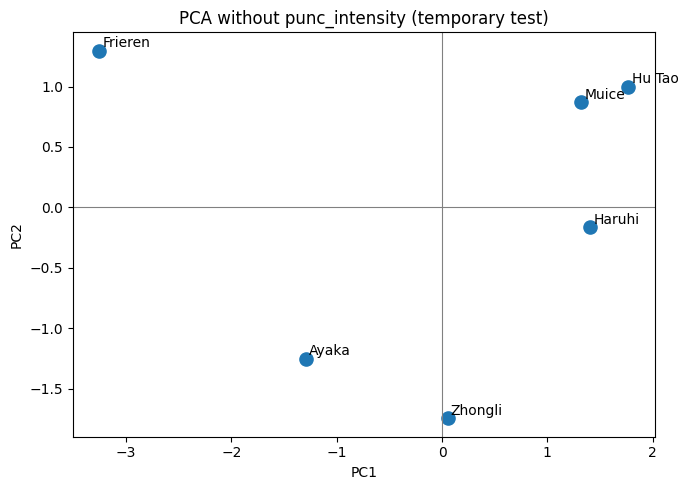

: 

In [ ]:
# Temporary test: drop `punc_intensity` and re-run PCA to inspect PC2
import numpy as np
import matplotlib.pyplot as plt

selected_features_no_punc = [
    "MDD",
    "verb_noun_ratio",
    "question_ratio",
    "imperative_ratio",
    "fragment_ratio",
    "marker_density",
]

X2 = df[selected_features_no_punc].to_numpy(dtype=float)
mu2 = X2.mean(axis=0, keepdims=True)
sigma2 = X2.std(axis=0, ddof=0, keepdims=True)
sigma2[sigma2 == 0] = 1.0
Z2 = (X2 - mu2) / sigma2
U2, S2, Vt2 = np.linalg.svd(Z2, full_matrices=False)
scores2 = U2 * S2
eig2 = (S2 ** 2) / (len(Z2) - 1) if len(Z2) > 1 else np.array([0.0] * len(S2))
expl2 = eig2 / eig2.sum() if eig2.sum() > 0 else np.zeros_like(eig2)

print("Selected features (no punc):", selected_features_no_punc)
print("Explained variance ratio (no punc) by component:")
for i, r in enumerate(expl2, start=1):
    print(f"  PC{i}: {r:.4f}")
pc12_2 = expl2[:2].sum() if expl2.size >= 2 else expl2.sum()

# Loadings for inspection
pc1_w2 = Vt2[0, :] if Vt2.shape[0] > 0 else np.zeros(len(selected_features_no_punc))
pc2_w2 = Vt2[1, :] if Vt2.shape[0] > 1 else np.zeros(len(selected_features_no_punc))
load2 = pd.DataFrame({
    "feature": selected_features_no_punc,
    "PC1_weight": pc1_w2,
    "PC2_weight": pc2_w2,
})
load2["|PC2|"] = load2["PC2_weight"].abs()
print("\nTop contributions to PC2 (no punc):")
display(load2.sort_values("|PC2|", ascending=False).reset_index(drop=True).round(4))

# Simple scatter for visual check
pc_df2 = df[["role"]].copy()
pc_df2["role_en"] = pc_df2["role"].map(role_en_map).fillna(pc_df2["role"])
pc_df2["PC1"] = scores2[:, 0] if scores2.shape[1] > 0 else 0.0
pc_df2["PC2"] = scores2[:, 1] if scores2.shape[1] > 1 else 0.0
plt.figure(figsize=(7,5))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.scatter(pc_df2["PC1"], pc_df2["PC2"], s=90)
for _, r in pc_df2.iterrows():
    plt.text(r["PC1"]+0.03, r["PC2"]+0.03, r["role_en"], fontsize=10)
plt.title("PCA without punc_intensity (temporary test)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# NOTE: remove this cell after inspection if desired.

### PCA Loadings Analysis for PC1 and PC2
This section reports feature weights (loadings) on the first two principal components, enabling direct interpretation of which dimensions dominate each axis in the reduced space.

PCA loadings for PC1 and PC2:


,feature,PC1_weight,PC2_weight,|PC1_weight|,|PC2_weight|,PC1_contrib_share,PC2_contrib_share
0,MDD,-0.2818,0.5861,0.2818,0.5861,0.1160,0.2641
1,verb_noun_ratio,0.0768,-0.5362,0.0768,0.5362,0.0316,0.2416
2,question_ratio,-0.4875,-0.2009,0.4875,0.2009,0.2006,0.0905
3,imperative_ratio,-0.5186,-0.0672,0.5186,0.0672,0.2134,0.0303
4,fragment_ratio,-0.4860,0.1190,0.4860,0.1190,0.2000,0.0536
5,marker_density,-0.2430,0.1849,0.2430,0.1849,0.1000,0.0833
6,punc_intensity,-0.3358,-0.5252,0.3358,0.5252,0.1382,0.2366



Top features by absolute loading on PC1:


,feature,PC1_weight,PC1_contrib_share
0,imperative_ratio,-0.5186,0.2134
1,question_ratio,-0.4875,0.2006
2,fragment_ratio,-0.4860,0.2000
3,punc_intensity,-0.3358,0.1382
4,MDD,-0.2818,0.1160
5,marker_density,-0.2430,0.1000
6,verb_noun_ratio,0.0768,0.0316


Top features by absolute loading on PC2:


,feature,PC2_weight,PC2_contrib_share
0,MDD,0.5861,0.2641
1,verb_noun_ratio,-0.5362,0.2416
2,punc_intensity,-0.5252,0.2366
3,question_ratio,-0.2009,0.0905
4,marker_density,0.1849,0.0833
5,fragment_ratio,0.1190,0.0536
6,imperative_ratio,-0.0672,0.0303


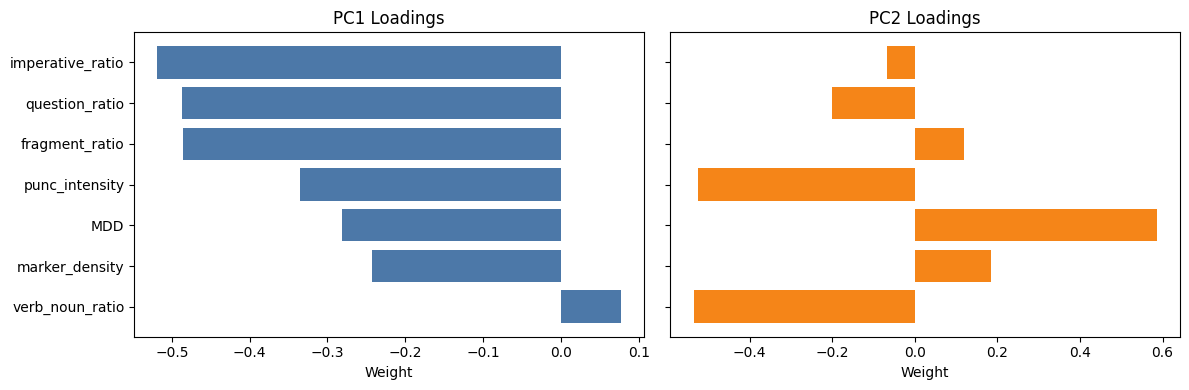

,feature,PC1_weight,PC2_weight,|PC1_weight|,|PC2_weight|,PC1_contrib_share,PC2_contrib_share
0,MDD,-0.281837,0.586089,0.281837,0.586089,0.115999,0.264076
1,verb_noun_ratio,0.076836,-0.536154,0.076836,0.536154,0.031625,0.241577
2,question_ratio,-0.487505,-0.200913,0.487505,0.200913,0.200649,0.090526
3,imperative_ratio,-0.518595,-0.067152,0.518595,0.067152,0.213445,0.030257
4,fragment_ratio,-0.486027,0.118998,0.486027,0.118998,0.200040,0.053618
5,marker_density,-0.243003,0.184905,0.243003,0.184905,0.100016,0.083313
6,punc_intensity,-0.335840,-0.525179,0.335840,0.525179,0.138226,0.236632


In [10]:
# PCA component vectors (eigenvectors) for PC1 and PC2.
# In this SVD formulation, Vt rows correspond to principal axes in standardized feature space.
pc1_weights = Vt[0, :] if Vt.shape[0] > 0 else np.zeros(len(selected_features))
pc2_weights = Vt[1, :] if Vt.shape[0] > 1 else np.zeros(len(selected_features))

loadings_df = pd.DataFrame({
    "feature": selected_features,
    "PC1_weight": pc1_weights,
    "PC2_weight": pc2_weights,
})

# Add absolute magnitudes and normalized contribution shares for interpretability.
loadings_df["|PC1_weight|"] = loadings_df["PC1_weight"].abs()
loadings_df["|PC2_weight|"] = loadings_df["PC2_weight"].abs()
loadings_df["PC1_contrib_share"] = loadings_df["|PC1_weight|"] / loadings_df["|PC1_weight|"].sum()
loadings_df["PC2_contrib_share"] = loadings_df["|PC2_weight|"] / loadings_df["|PC2_weight|"].sum()

print("PCA loadings for PC1 and PC2:")
display(loadings_df.round(4))

print("\nTop features by absolute loading on PC1:")
display(loadings_df.sort_values("|PC1_weight|", ascending=False)[[
    "feature", "PC1_weight", "PC1_contrib_share"
]].head(7).reset_index(drop=True).round(4))

print("Top features by absolute loading on PC2:")
display(loadings_df.sort_values("|PC2_weight|", ascending=False)[[
    "feature", "PC2_weight", "PC2_contrib_share"
]].head(7).reset_index(drop=True).round(4))

# Optional bar charts for paper-ready interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sorted_pc1 = loadings_df.sort_values("|PC1_weight|", ascending=True)
sorted_pc2 = loadings_df.sort_values("|PC2_weight|", ascending=True)

axes[0].barh(sorted_pc1["feature"], sorted_pc1["PC1_weight"], color="#4C78A8")
axes[0].set_title("PC1 Loadings")
axes[0].set_xlabel("Weight")

axes[1].barh(sorted_pc2["feature"], sorted_pc2["PC2_weight"], color="#F58518")
axes[1].set_title("PC2 Loadings")
axes[1].set_xlabel("Weight")

plt.tight_layout()
plt.show()

loadings_df